<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Florencia Vanella


# Consigna

Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

- frecuencia $f0$ arbitraria, por ejemplo $f0=fS/N=Δf$
 
- energía normalizada, es decir energía (o varianza) unitaria

Con respecto a los parámetros de la secuencia de ruido, diremos que:

- será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n
    . Siendo $n$ la secuencia que simula la interferencia, y $s$ la senoidal descrita anteriormente.
- La potencia del ruido será $Pn=kn.Pq$ W siendo el factor k una escala para la potencia del ruido de cuantización $Pq=q^2/12$
- finalmente, $n$ será incorrelado y Gaussiano.
El ADC que deseamos simular trabajará a una frecuencia de muestreo $fS=1000Hz$ y tendrá un rango analógico de $±VF=2$ Volts.

Se pide:


### a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1

Potencia de la señal (Px): 1.0000000000000002


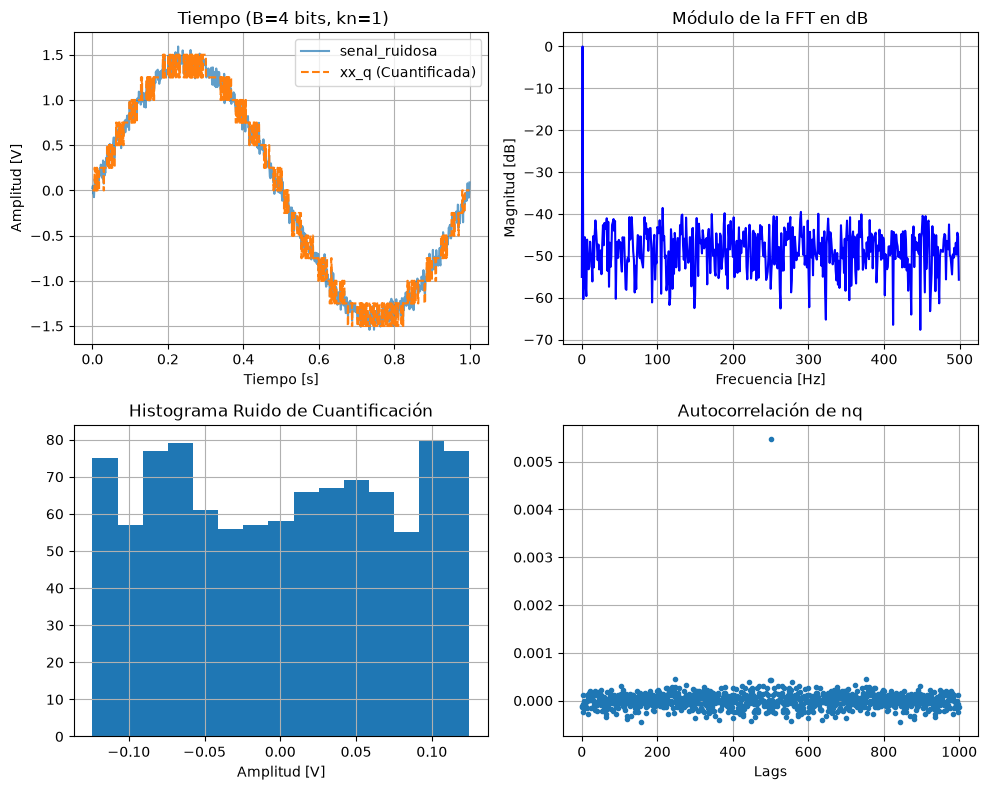

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import math 
from matplotlib.pyplot import subplot
import scipy.stats as stats
from scipy.stats import kstest

fs = 1000   # Hz - frecuencia de muestreo
N = 1000 
ts = 1/fs  

# Función para generar una señal senoidal
def mi_funcion_sen(vmax= math.sqrt(2), dc=0, ff=3, ph=0, nn=N, fs=fs):
    ts = 1 / fs                     # tiempo entre cada muestra
    tt = np.arange(0, nn) * ts      # tiempo de cada muestra
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return(tt, xx)

# Generación de la senoidal pura (1W) con f0 = fs/N = 1 Hz (Delta f)
f0 = fs / N
vmax = math.sqrt(2)      # amplitud
dc = 0          # desplazamiento vertical
ff = f0         # frecuencia f0 = Delta f
ph = 0          # fase
nn = N 

tt = np.arange(0, nn) * ts
xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

px = np.var(xx)
print("Potencia de la señal (Px):", px)

# Rango analógico +/- Vf = 2 Volts
Vfs = 2


# A) B = 4 bits, kn = 1
B = 4
kn = 1

# Cálculo del paso de cuantización (qq) y su potencia (Pq)
qq = 2 * Vfs / (2**B)
Pq = (qq**2) / 12

# Potencia del ruido aditivo Pn = kn * Pq
P_ruido = kn * Pq

sigma = np.sqrt(P_ruido)  # Desviación estándar del ruido

# Generar la secuencia aleatoria de ruido gaussiano 
rng = np.random.default_rng()
ruido = rng.normal(0, sigma, size=xx.shape)

# Adición de la señal y el ruido 
senal_ruidosa = xx + ruido

# CUANTIZACIÓN ADC
xx_q = np.round(senal_ruidosa / qq) * qq

nq = xx_q - senal_ruidosa # Ruido de cuantización

# FFT de la señal cuantificada xx_q
X_q = 1/N * np.fft.fft(xx_q)
freqs = np.arange(N//2) * fs/N
modulo_q = np.abs(X_q[:N//2])  
mod_ruido_db_q = 10 * np.log10(2 * modulo_q**2)

# --- Gráficos del Inciso a) ---
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.plot(tt, senal_ruidosa, label="senal_ruidosa", alpha=0.7)
plt.plot(tt, xx_q, label="xx_q (Cuantificada)", linestyle="--", drawstyle="steps-mid")
plt.title(" Tiempo (B=4 bits, kn=1)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(freqs, mod_ruido_db_q, color='blue')
plt.title("Módulo de la FFT en dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.hist(nq, bins=15)
plt.title("Histograma Ruido de Cuantificación")
plt.xlabel("Amplitud [V]")
plt.grid(True)

plt.subplot(2, 2, 4)
correlacion = np.correlate(nq, nq, "same") / N
plt.plot(correlacion, linestyle=" ", marker=".")
plt.title("Autocorrelación de nq")
plt.xlabel("Lags")
plt.grid(True)

plt.tight_layout()
plt.show()


### b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}

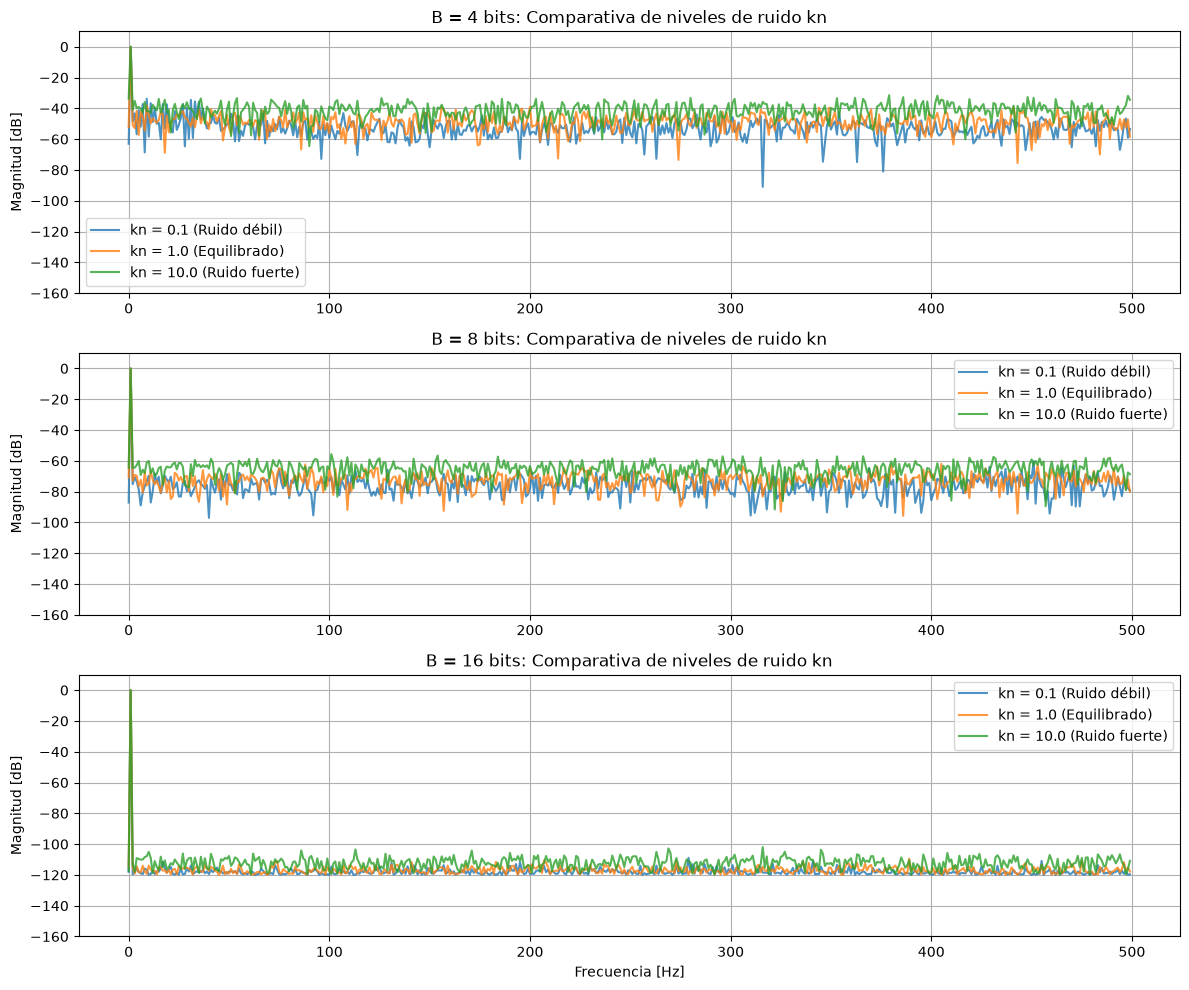

In [2]:
# BLOQUE B = 4 bits
q_B4 = (2 * Vfs) / (2**4)
Pq_B4 = (q_B4**2) / 12

# Función para calcular la FFT normalizada y convertir el módulo a dB
def espectro_db(senal, N):
    X = (1 / N) * np.fft.fft(senal)
    modulo = np.abs(X[0 : N // 2])
    espectro_db = 10 * np.log10(2 * modulo**2 + 1e-12)
    return espectro_db

# B=4, kn=0.1
r1 = rng.normal(0, np.sqrt(0.1 * Pq_B4), N)
s1_q = np.round((xx + r1) / q_B4) * q_B4
fft1 =espectro_db(s1_q, N)

# B=4, kn=1
r2 = rng.normal(0, np.sqrt(1.0 * Pq_B4), N)
s2_q = np.round((xx + r2) / q_B4) * q_B4
fft2 =espectro_db(s2_q, N)

# B=4, kn=10
r3 = rng.normal(0, np.sqrt(10.0 * Pq_B4), N)
s3_q = np.round((xx + r3) / q_B4) * q_B4
fft3 =espectro_db(s3_q, N)



# BLOQUE B = 8 bits
q_B8 = (2 * Vfs) / (2**8)
Pq_B8 = (q_B8**2) / 12

# B=8, kn=0.1
r4 = rng.normal(0, np.sqrt(0.1 * Pq_B8), N)
s4_q = np.round((xx + r4) / q_B8) * q_B8
fft4 =espectro_db(s4_q, N)

# B=8, kn=1
r5 = rng.normal(0, np.sqrt(1.0 * Pq_B8), N)
s5_q = np.round((xx + r5) / q_B8) * q_B8
fft5 =espectro_db(s5_q, N)

# B=8, kn=10
r6 = rng.normal(0, np.sqrt(10.0 * Pq_B8), N)
s6_q = np.round((xx + r6) / q_B8) * q_B8
fft6 =espectro_db(s6_q, N)

# BLOQUE B = 16 bits

q_B16 = (2 * Vfs) / (2**16)
Pq_B16 = (q_B16**2) / 12

# B=16, kn=0.1
r7 = rng.normal(0, np.sqrt(0.1 * Pq_B16), N)
s7_q = np.round((xx + r7) / q_B16) * q_B16
fft7 =espectro_db(s7_q, N)

# B=16, kn=1
r8 = rng.normal(0, np.sqrt(1.0 * Pq_B16), N)
s8_q = np.round((xx + r8) / q_B16) * q_B16
fft8 =espectro_db(s8_q, N)

# B=16, kn=10
r9 = rng.normal(0, np.sqrt(10.0 * Pq_B16), N)
s9_q = np.round((xx + r9) / q_B16) * q_B16
fft9 =espectro_db(s9_q, N)


# 1. Gráfico para B = 4 bits (Sus 3 kn juntos)
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(freqs, fft1, label="kn = 0.1 (Ruido débil)", alpha=0.8)
plt.plot(freqs, fft2, label="kn = 1.0 (Equilibrado)", alpha=0.8)
plt.plot(freqs, fft3, label="kn = 10.0 (Ruido fuerte)", alpha=0.8)
plt.title("B = 4 bits: Comparativa de niveles de ruido kn")
plt.ylabel("Magnitud [dB]")
plt.ylim([-160, 10])
plt.grid(True)
plt.legend()

# 2. Gráfico para B = 8 bits (Sus 3 kn juntos)
plt.subplot(3, 1, 2)
plt.plot(freqs, fft4, label="kn = 0.1 (Ruido débil)", alpha=0.8)
plt.plot(freqs, fft5, label="kn = 1.0 (Equilibrado)", alpha=0.8)
plt.plot(freqs, fft6, label="kn = 10.0 (Ruido fuerte)", alpha=0.8)
plt.title("B = 8 bits: Comparativa de niveles de ruido kn")
plt.ylabel("Magnitud [dB]")
plt.ylim([-160, 10])
plt.grid(True)
plt.legend()

# 3. Gráfico para B = 16 bits (Sus 3 kn juntos)
plt.subplot(3, 1, 3)
plt.plot(freqs, fft7, label="kn = 0.1 (Ruido débil)", alpha=0.8)
plt.plot(freqs, fft8, label="kn = 1.0 (Equilibrado)", alpha=0.8)
plt.plot(freqs, fft9, label="kn = 10.0 (Ruido fuerte)", alpha=0.8)
plt.title("B = 16 bits: Comparativa de niveles de ruido kn")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.ylim([-160, 10])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

A medida que aumentamos la resolución de cuantificador (de 4 a 16 bits), el paso de cuantización $q$ se vuelve más chico. Esto hace que el piso de ruido general baje drásticamente en la FFT, pasando de estar alrededor de los $-45dB$ para 4 bits,
cerca de los $-75dB$ para 8 bits, y bajando hasta casi $-120dB$ cuando usamos 16 bits. Esto significa que el nivel de error es exponencialmente menor.

Para una misma cantidad de bits, cuanto mayor es $k_n$ ($10$ en verde vs $0.1$ en azul), más alta resulta la varianza del ruido sumado antes del ADC. Esto provoca que la curva verde quede sistemáticamente por encima de la azul en el piso de espectro. Ya que a a mayor $k_n$ mas ruido total entra al sistema.